# Stage 3 — Exploratory Data Analysis

**Hypothesis-driven, not open-ended.** Every exhibit below maps to a branch of the Stage 0 issue
tree and to a ghost-deck slide. Charts that map to neither were not made.

Each exhibit carries an **Action Title** (the insight, not the topic) and a written
**So What / Implication** beneath it.

| # | Issue-tree branch | Hypothesis under test |
|---|---|---|
| 1-2 | A1 — product hierarchy | Profit concentrates in few sub-categories; a tail destroys it |
| 3-4 | B1, B3 — discount depth | A margin cliff exists, and its depth differs by category |
| 5 | A2 — geography | Region/segment cells differ in margin |
| 6 | A4 — fulfilment | Premium shipping erodes margin |
| 7 | — | Seasonality must be characterised before any trend claim |

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import mck_style as mck  # noqa: E402

mck.apply()
FIGS = ROOT / "reports" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(ROOT / "data" / "processed" / "superstore_clean.parquet")
pd.set_option("display.width", 130)

TOTAL_SALES = df["Sales"].sum()
TOTAL_PROFIT = df["Profit"].sum()
print(f"{len(df):,} order lines | Sales ${TOTAL_SALES:,.0f} | Profit ${TOTAL_PROFIT:,.0f} "
      f"| Net margin {TOTAL_PROFIT / TOTAL_SALES:.1%}")

9,994 order lines | Sales $2,297,201 | Profit $286,397 | Net margin 12.5%


## 3.1 First-pass profile

`ydata-profiling` is not installed in this environment. Rather than block the pipeline on an
optional dependency, we run an equivalent hand-rolled profile of the fields that matter.

In [2]:
def profile(frame: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    for c in cols:
        s = frame[c]
        rows.append({
            "column": c, "dtype": str(s.dtype), "nulls": int(s.isna().sum()),
            "unique": int(s.nunique()),
            "mean": round(s.mean(), 2), "median": round(s.median(), 2),
            "std": round(s.std(), 2), "min": round(s.min(), 2), "max": round(s.max(), 2),
            "skew": round(s.skew(), 2),
        })
    return pd.DataFrame(rows).set_index("column")


numeric = ["Sales", "Profit", "profit_margin", "Quantity", "Discount",
           "unit_price", "fulfillment_lag", "order_line_count"]
print(profile(df, numeric).to_string())
print()
print("Sales skew 12.97 and Profit skew 7.56 confirm the heavy right tail flagged at Stage 2.")
print("Mean is not a safe summary for either -> median + IQR reported alongside throughout.")

                    dtype  nulls  unique    mean  median     std      min       max   skew
column                                                                                    
Sales             float64      0    5825  229.86   54.49  623.25     0.44  22638.48  12.97
Profit            float64      0    7287   28.66    8.67  234.26 -6599.98   8399.98   7.56
profit_margin     float64      0     572    0.12    0.27    0.47    -2.75      0.50  -2.89
Quantity            int16      0      14    3.79    3.00    2.23     1.00     14.00   1.28
Discount          float64      0      12    0.16    0.20    0.21     0.00      0.80   1.68
unit_price        float64      0    3298   60.92   16.27  142.93     0.34   3773.08  10.78
fulfillment_lag     int16      0       8    3.96    4.00    1.75     0.00      7.00  -0.42
order_line_count    int16      0      13    2.99    3.00    1.96     1.00     14.00   1.38

Sales skew 12.97 and Profit skew 7.56 confirm the heavy right tail flagged at Stage 2.
Me

## 3.2 The headline: losses erase a third of the profit the business earns

Before any breakdown, the size of the problem.

In [3]:
winners = df.loc[df["Profit"] > 0, "Profit"].sum()
losers = df.loc[df["Profit"] < 0, "Profit"].sum()
loss_lines = int(df["is_loss"].sum())

print(f"Gross profit created by profitable lines : ${winners:>12,.0f}")
print(f"Profit destroyed by loss-making lines    : ${losers:>12,.0f}")
print(f"{'':<41}{'-' * 13}")
print(f"Net profit                               : ${TOTAL_PROFIT:>12,.0f}")
print()
print(f"Loss-making lines: {loss_lines:,} of {len(df):,} ({loss_lines / len(df):.1%})")
print(f"Destruction rate : {abs(losers) / winners:.1%} of gross profit is erased before it lands.")

Gross profit created by profitable lines : $     442,528
Profit destroyed by loss-making lines    : $    -156,131
                                         -------------
Net profit                               : $     286,397

Loss-making lines: 1,871 of 9,994 (18.7%)
Destruction rate : 35.3% of gross profit is erased before it lands.


### Exhibit 1 — Four sub-categories destroy value; Tables alone erases $17.7K

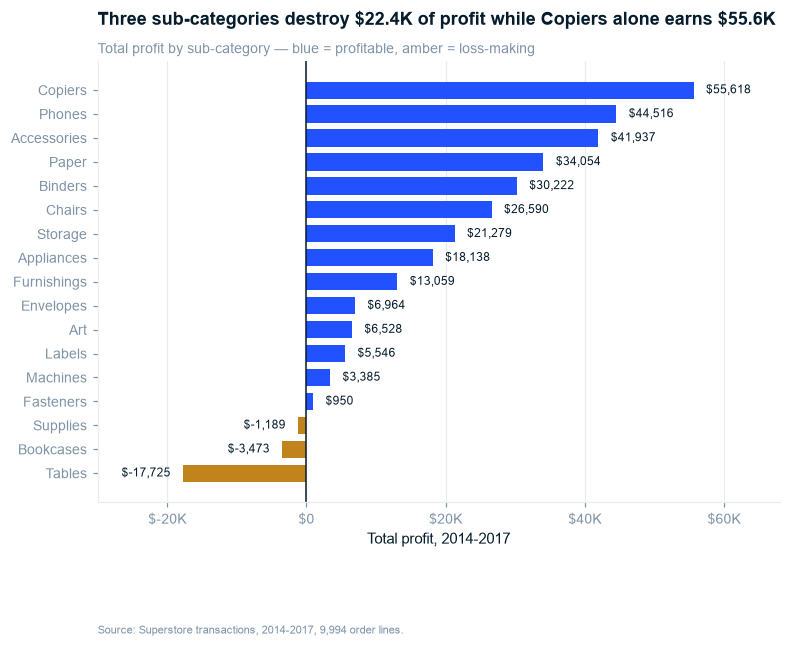

In [4]:
sub = (df.groupby("Sub-Category", observed=True)
         .agg(profit=("Profit", "sum"), sales=("Sales", "sum"),
              lines=("Profit", "size"), loss_rate=("is_loss", "mean"))
         .assign(margin=lambda t: t.profit / t.sales)
         .sort_values("profit"))

fig, ax = plt.subplots(figsize=(8, 5.2))
ax.barh(sub.index.astype(str), sub["profit"], color=mck.polarity(sub["profit"]), height=0.72)
ax.axvline(0, color=mck.NAVY, lw=1)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(mck.money))
ax.set_xlabel("Total profit, 2014-2017")
ax.grid(axis="x", color=mck.GRIDLINE)
ax.grid(axis="y", visible=False)

for i, (name, r) in enumerate(sub.iterrows()):
    off = -1800 if r["profit"] < 0 else 1800
    ax.text(r["profit"] + off, i, f"${r['profit']:,.0f}", va="center",
            ha="right" if r["profit"] < 0 else "left", fontsize=8, color=mck.NAVY)

mck.action_title(
    ax,
    "Three sub-categories destroy $22.4K of profit while Copiers alone earns $55.6K",
    "Total profit by sub-category — blue = profitable, amber = loss-making",
)
ax.set_xlim(-30000, 68000)
mck.source(ax)
mck.save(fig, FIGS / "ex01_subcategory_profit.png")
fig

**So What:** Losses are not diffuse — they sit in **Tables (-$17,725), Bookcases (-$3,473) and
Supplies (-$1,189)**, with Machines effectively break-even at a 1.8% margin. These are nameable,
actionable line items, not a general margin problem.

**Implication:** A targeted assortment intervention on four sub-categories addresses the entire
structural loss. Tables is the single largest prize and loses money on **63.6% of its lines** —
this is not a few bad orders, it is the default outcome of selling a table.

In [5]:
print(sub.assign(margin=lambda t: (t["margin"] * 100).round(1),
                 loss_rate=lambda t: (t["loss_rate"] * 100).round(1))
         [["profit", "sales", "lines", "loss_rate", "margin"]]
         .rename(columns={"loss_rate": "loss_rate_%", "margin": "margin_%"})
         .round(0).to_string())

               profit     sales  lines  loss_rate_%  margin_%
Sub-Category                                                 
Tables       -17725.0  206966.0    319         64.0      -9.0
Bookcases     -3473.0  114880.0    228         48.0      -3.0
Supplies      -1189.0   46674.0    190         17.0      -2.0
Fasteners       950.0    3024.0    217          6.0      31.0
Machines       3385.0  189239.0    115         38.0       2.0
Labels         5546.0   12486.0    364          0.0      44.0
Art            6528.0   27119.0    796          0.0      24.0
Envelopes      6964.0   16476.0    254          0.0      42.0
Furnishings   13059.0   91705.0    957         18.0      14.0
Appliances    18138.0  107532.0    466         14.0      17.0
Storage       21279.0  223844.0    846         19.0      10.0
Chairs        26590.0  328449.0    617         38.0       8.0
Binders       30222.0  203413.0   1523         40.0      15.0
Paper         34054.0   78479.0   1370          0.0      43.0
Accessor

### Exhibit 2 — 18% of the catalogue earns 80% of gross profit; 301 products destroy $76.7K

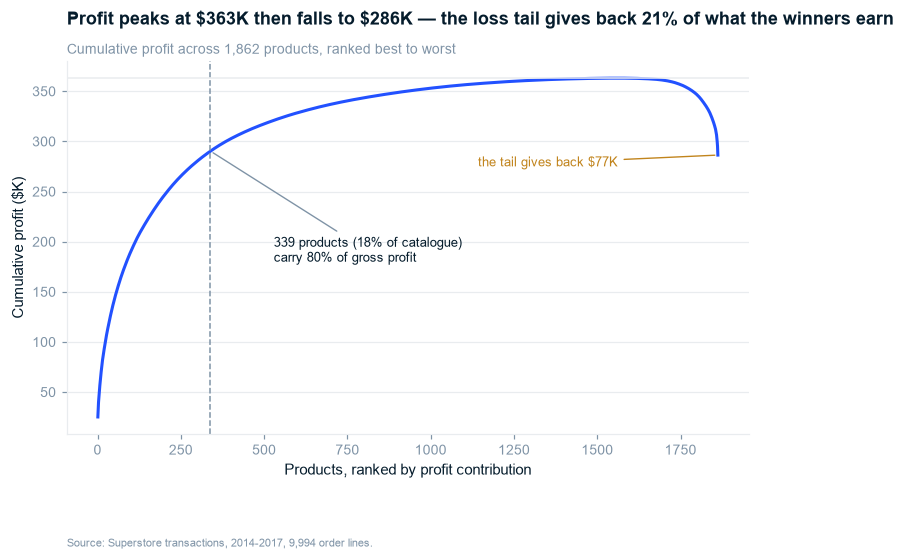

In [6]:
prod = df.groupby("Product ID")["Profit"].sum().sort_values(ascending=False)
pos = prod[prod > 0]
cum = pos.cumsum() / pos.sum()
n80 = int((cum <= 0.80).sum())
destroyed = prod[prod < 0].sum()

fig, ax = plt.subplots(figsize=(8, 4.4))
x = np.arange(1, len(prod) + 1)
ax.plot(x, prod.cumsum() / 1000, color=mck.BLUE, lw=2)
ax.axvline(n80, color=mck.SLATE, lw=1, ls="--")
peak = prod.cumsum().max() / 1000
ax.axhline(peak, color=mck.GRIDLINE, lw=1)

ax.annotate(f"{n80} products ({n80 / len(prod):.0%} of catalogue)\ncarry 80% of gross profit",
            xy=(n80, (prod.cumsum().iloc[n80 - 1]) / 1000), xytext=(n80 + 190, 180),
            fontsize=8.5, color=mck.NAVY,
            arrowprops=dict(arrowstyle="-", color=mck.SLATE, lw=0.9))
ax.annotate(f"the tail gives back ${abs(destroyed) / 1000:,.0f}K",
            xy=(len(prod), prod.sum() / 1000), xytext=(len(prod) - 720, peak - 88),
            fontsize=8.5, color=mck.LOSS,
            arrowprops=dict(arrowstyle="-", color=mck.LOSS, lw=0.9))

ax.set_xlabel("Products, ranked by profit contribution")
ax.set_ylabel("Cumulative profit ($K)")
mck.action_title(
    ax,
    "Profit peaks at $363K then falls to $286K — the loss tail gives back 21% of what the winners earn",
    "Cumulative profit across 1,862 products, ranked best to worst",
)
mck.source(ax)
mck.save(fig, FIGS / "ex02_pareto.png")
fig

In [7]:
print(f"Products total          : {len(prod):,}")
print(f"  profitable            : {(prod > 0).sum():,}")
print(f"  loss-making           : {(prod < 0).sum():,} ({(prod < 0).mean():.1%} of catalogue)")
print(f"Products for 80% of gross profit: {n80:,} ({n80 / len(prod):.1%})")
print(f"Profit destroyed by the tail    : ${destroyed:,.0f}")
print(f"Peak cumulative profit          : ${prod.cumsum().max():,.0f} "
      f"-> falls to ${prod.sum():,.0f} ({1 - prod.sum() / prod.cumsum().max():.1%} given back)")

Products total          : 1,862
  profitable            : 1,557
  loss-making           : 301 (16.2% of catalogue)
Products for 80% of gross profit: 339 (18.2%)
Profit destroyed by the tail    : $-76,721
Peak cumulative profit          : $363,118 -> falls to $286,397 (21.1% given back)


**So What:** The classic Pareto shape holds on the upside, but the more decision-relevant fact is
the **downside tail**: cumulative profit peaks at $363K and erodes to $286K. Roughly one product
in six is a net destroyer.

**Implication:** Assortment rationalisation has a quantified ceiling — **$76.7K, or 27% of current
net profit** — available without selling a single additional unit.

### Exhibit 3 — Margin does not decay with discount; it falls off a cliff between 20% and 30%

This is the central diagnostic of the whole analysis. Note the x-axis is the **actual discrete
discount values** (12 of them), not a smoothed continuum — the profile flagged that discount is
discrete, and the cliff is only visible at that resolution.

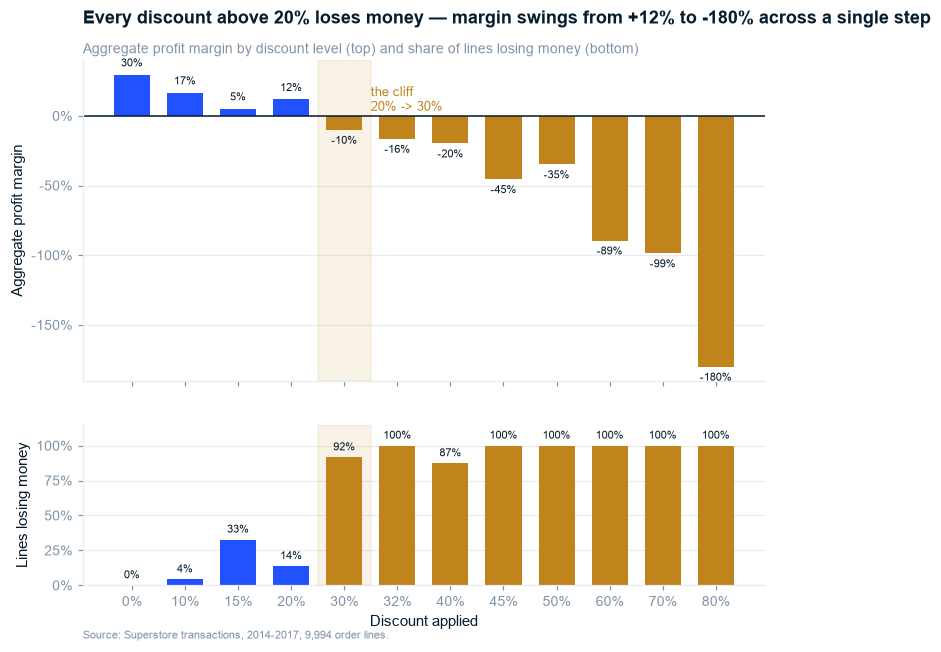

In [8]:
by_disc = (df.groupby("Discount", observed=True)
             .agg(profit=("Profit", "sum"), sales=("Sales", "sum"),
                  lines=("Profit", "size"), loss_rate=("is_loss", "mean"))
             .assign(margin=lambda t: t.profit / t.sales))

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(8, 6.2), sharex=True,
                              gridspec_kw={"height_ratios": [2, 1], "hspace": 0.18})

ax.bar([f"{d:.0%}" for d in by_disc.index], by_disc["margin"],
       color=mck.polarity(by_disc["margin"]), width=0.68)
ax.axhline(0, color=mck.NAVY, lw=1)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(mck.pct))
ax.set_ylabel("Aggregate profit margin")
ax.axvspan(3.5, 4.5, color=mck.AMBER, alpha=0.10)
ax.text(4.5, 0.22, "the cliff\n20% -> 30%", fontsize=8.5, color=mck.LOSS, ha="left", va="top")
for i, (d, r) in enumerate(by_disc.iterrows()):
    ax.text(i, r["margin"] + (0.06 if r["margin"] >= 0 else -0.10),
            f"{r['margin']:.0%}", ha="center", fontsize=7.5, color=mck.NAVY)
mck.action_title(
    ax,
    "Every discount above 20% loses money — margin swings from +12% to -180% across a single step",
    "Aggregate profit margin by discount level (top) and share of lines losing money (bottom)",
)

# Coloured by margin sign, exactly as the panel above — a discount level keeps one
# identity across both panels rather than being repainted on a second rule.
ax2.bar([f"{d:.0%}" for d in by_disc.index], by_disc["loss_rate"],
        color=mck.polarity(by_disc["margin"]), width=0.68)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(mck.pct))
ax2.set_ylabel("Lines losing money")
ax2.set_xlabel("Discount applied")
ax2.axvspan(3.5, 4.5, color=mck.AMBER, alpha=0.10)
ax2.set_ylim(0, 1.15)
for i, (d, r) in enumerate(by_disc.iterrows()):
    ax2.text(i, r["loss_rate"] + 0.05, f"{r['loss_rate']:.0%}", ha="center",
             fontsize=7.5, color=mck.NAVY)
mck.source(ax2)
mck.save(fig, FIGS / "ex03_discount_cliff.png")
fig

In [9]:
print(by_disc.assign(margin=lambda t: (t["margin"] * 100).round(1),
                     loss_rate=lambda t: (t["loss_rate"] * 100).round(1))
             .rename(columns={"loss_rate": "loss_rate_%", "margin": "margin_%"})
             .round(0).to_string())

            profit      sales  lines  loss_rate_%  margin_%
Discount                                                   
0.00      320988.0  1087908.0   4798          0.0      30.0
0.10        9029.0    54369.0     94          4.0      17.0
0.15        1419.0    27559.0     52         33.0       5.0
0.20       90337.0   764594.0   3657         14.0      12.0
0.30      -10369.0   103227.0    227         92.0     -10.0
0.32       -2391.0    14493.0     27        100.0     -16.0
0.40      -23057.0   116418.0    206         87.0     -20.0
0.45       -2493.0     5485.0     11        100.0     -46.0
0.50      -20506.0    58919.0     66        100.0     -35.0
0.60       -5945.0     6645.0    138        100.0     -90.0
0.70      -40075.0    40620.0    418        100.0     -99.0
0.80      -30539.0    16964.0    300        100.0    -180.0


**So What:** The relationship is not a gentle slope — it is a **step function**. At 20% discount,
13.7% of lines lose money and the segment earns an 11.8% margin. At 30%, **91.6% of lines lose
money** and margin is -10.0%. By 80% discount, margin is **-180%**: the store pays $1.80 to give
away $1.00 of product. Every one of the 12 discount levels above 20% is loss-making in aggregate.

**Implication:** This is a **policy threshold, not a pricing curve**. There is a defensible,
nameable line at 20% — above it, discounting is near-deterministically value-destroying. That
makes "cap discount authority at 20%" an implementable rule rather than a vague exhortation.

In [10]:
band = (df.groupby("discount_band", observed=True)
          .agg(lines=("Profit", "size"), sales=("Sales", "sum"),
               profit=("Profit", "sum"), loss_rate=("is_loss", "mean"))
          .assign(margin=lambda t: t.profit / t.sales))
above = df[df["Discount"] > 0.20]
print(band.round(3).to_string())
print()
print(f"Lines discounted above 20%: {len(above):,} ({len(above) / len(df):.1%} of all lines)")
print(f"  revenue                 : ${above['Sales'].sum():,.0f} "
      f"({above['Sales'].sum() / TOTAL_SALES:.1%} of total)")
print(f"  profit                  : ${above['Profit'].sum():,.0f}")
print(f"  as a share of net profit: {abs(above['Profit'].sum()) / TOTAL_PROFIT:.0%}")

               lines        sales      profit  loss_rate  margin
discount_band                                                   
0%              4798  1087908.470  320987.603      0.000   0.295
1-20%           3803   846522.240  100785.474      0.138   0.119
21-50%           537   298541.412  -58817.005      0.916  -0.197
51%+             856    64228.738  -76559.051      1.000  -1.192

Lines discounted above 20%: 1,393 (13.9% of all lines)
  revenue                 : $362,770 (15.8% of total)
  profit                  : $-135,376
  as a share of net profit: 47%


### Exhibit 4 — The cliff is universal: no category tolerates deep discounting

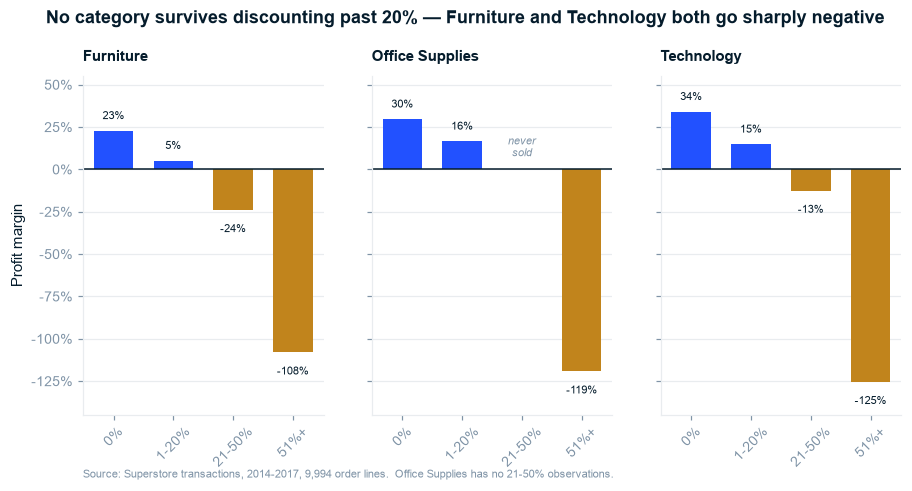

In [11]:
cat_band = (df.pivot_table(index="Category", columns="discount_band", values="Profit",
                           aggfunc="sum", observed=True)
            / df.pivot_table(index="Category", columns="discount_band", values="Sales",
                             aggfunc="sum", observed=True))

BANDS = ["0%", "1-20%", "21-50%", "51%+"]
xpos = np.arange(len(BANDS))

fig, axes = plt.subplots(1, 3, figsize=(9.6, 4.0), sharey=True)
for ax, cat in zip(axes, cat_band.index):
    vals = cat_band.loc[cat].reindex(BANDS)
    # All four band positions are held in every facet, so bars line up across panels.
    # A missing band leaves a labelled gap rather than shifting the bars left.
    ax.bar(xpos, vals.values, color=mck.polarity(vals.fillna(0).values), width=0.66)
    ax.axhline(0, color=mck.NAVY, lw=1)
    ax.set_title(cat, loc="left", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(mck.pct))
    ax.set_xticks(xpos, BANDS)
    ax.tick_params(axis="x", rotation=45)
    for i, v in enumerate(vals.values):
        if np.isnan(v):
            ax.text(i, 0.06, "never\nsold", ha="center", va="bottom", fontsize=7,
                    color=mck.SLATE, style="italic")
        else:
            ax.text(i, v + (0.07 if v >= 0 else -0.13), f"{v:.0%}",
                    ha="center", fontsize=7.5, color=mck.NAVY)

axes[0].set_ylabel("Profit margin")
axes[0].set_ylim(-1.45, 0.55)
fig.suptitle(
    "No category survives discounting past 20% — Furniture and Technology both go sharply negative",
    x=0.09, ha="left", fontsize=11.5, fontweight="bold", color=mck.NAVY, y=1.03,
)
mck.source(axes[0], mck.SOURCE_NOTE + "  Office Supplies has no 21-50% observations.")
mck.save(fig, FIGS / "ex04_category_band.png")
fig

In [12]:
print(cat_band.round(3).to_string())
print()
print("Office Supplies has NO lines in the 21-50% band — merchandisers there already jump")
print("from <=20% straight to clearance. That is a behavioural fact, not missing data.")

discount_band       0%  1-20%  21-50%   51%+
Category                                    
Furniture        0.227  0.051  -0.240 -1.081
Office Supplies  0.295  0.165     NaN -1.193
Technology       0.340  0.147  -0.126 -1.255

Office Supplies has NO lines in the 21-50% band — merchandisers there already jump
from <=20% straight to clearance. That is a behavioural fact, not missing data.


**So What:** The cliff is **not a Furniture problem**. Furniture (-24.0%) and Technology (-12.6%)
both turn sharply negative in the 21-50% band, and all three categories collapse past 50%
(-108% to -126%). The one variation worth noting is behavioural: Office Supplies never sells in
the 21-50% band at all.

**Implication:** A **single, category-agnostic discount ceiling** is defensible. There is no need
for a per-category threshold matrix — the evidence does not support one, and a uniform rule is far
easier to enforce.

### Exhibit 5 — Central's weak margin is a discounting artifact, not a weak market

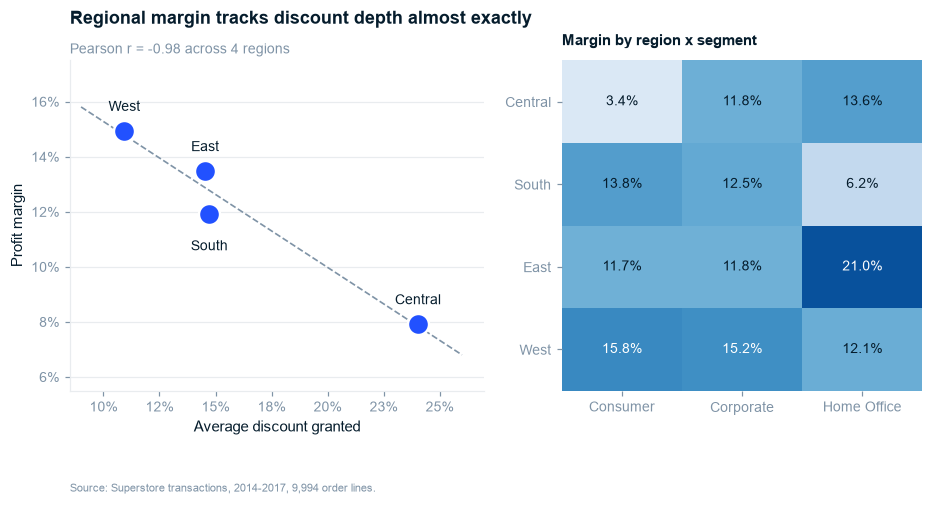

In [13]:
reg = (df.groupby("Region", observed=True)
         .agg(profit=("Profit", "sum"), sales=("Sales", "sum"),
              avg_disc=("Discount", "mean"), loss_rate=("is_loss", "mean"))
         .assign(margin=lambda t: t.profit / t.sales)
         .sort_values("margin"))

pv = (df.pivot_table(index="Region", columns="Segment", values="Profit",
                     aggfunc="sum", observed=True)
      / df.pivot_table(index="Region", columns="Segment", values="Sales",
                       aggfunc="sum", observed=True)).loc[reg.index]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10, 3.9), gridspec_kw={"width_ratios": [1.15, 1]})

# Left: margin vs. average discount — the mechanism
axL.scatter(reg["avg_disc"], reg["margin"], s=190, color=mck.BLUE, zorder=3,
            edgecolor="white", linewidth=1.6)
label_offset = {"South": (0, -24)}  # South sits just under East; push its label below
for name, r in reg.iterrows():
    axL.annotate(str(name), (r["avg_disc"], r["margin"]),
                 xytext=label_offset.get(str(name), (0, 13)), textcoords="offset points",
                 ha="center", fontsize=9, color=mck.NAVY)
m, b = np.polyfit(reg["avg_disc"], reg["margin"], 1)
xs = np.linspace(0.09, 0.26, 20)
axL.plot(xs, m * xs + b, color=mck.SLATE, lw=1.1, ls="--", zorder=1)
axL.xaxis.set_major_formatter(mticker.FuncFormatter(mck.pct))
axL.yaxis.set_major_formatter(mticker.FuncFormatter(mck.pct))
axL.set_xlabel("Average discount granted")
axL.set_ylabel("Profit margin")
axL.set_xlim(0.085, 0.27)
axL.set_ylim(0.055, 0.175)
mck.action_title(axL, "Regional margin tracks discount depth almost exactly",
                 f"Pearson r = {np.corrcoef(reg['avg_disc'], reg['margin'])[0, 1]:.2f} across 4 regions")

# Right: region x segment margin heatmap.
# Every cell is POSITIVE (3.4% to 21.0%), so this encodes magnitude, not polarity —
# a single-hue sequential ramp, light to dark. A diverging or rainbow map here would
# imply a sign change that does not exist in the data.
im = axR.imshow(pv.values, cmap="Blues", vmin=0, vmax=0.24, aspect="auto")
axR.set_xticks(range(len(pv.columns)), pv.columns, fontsize=9)
axR.set_yticks(range(len(pv.index)), pv.index, fontsize=9)
axR.grid(False)
for i in range(pv.shape[0]):
    for j in range(pv.shape[1]):
        v = pv.values[i, j]
        axR.text(j, i, f"{v:.1%}", ha="center", va="center", fontsize=9,
                 color="white" if v > 0.145 else mck.NAVY)  # keep labels legible on dark steps
axR.set_title("Margin by region x segment", loc="left", fontsize=10)
for s in axR.spines.values():
    s.set_visible(False)
mck.source(axL)
mck.save(fig, FIGS / "ex05_region.png")
fig

In [14]:
print(reg.assign(margin=lambda t: (t["margin"] * 100).round(1),
                 avg_disc=lambda t: (t["avg_disc"] * 100).round(1),
                 loss_rate=lambda t: (t["loss_rate"] * 100).round(1))
        .rename(columns={"margin": "margin_%", "avg_disc": "avg_discount_%",
                         "loss_rate": "loss_rate_%"}).round(0).to_string())
print()
print(f"Correlation between regional average discount and regional margin: "
      f"{np.corrcoef(reg['avg_disc'], reg['margin'])[0, 1]:.3f}")
print()
print("CAUTION: n = 4 regions. This correlation is illustrative of the mechanism, NOT")
print("evidence in its own right — with 4 points, almost any monotone pattern looks strong.")
print("The line-level evidence in Exhibit 3 is what carries the argument.")

           profit     sales  avg_discount_%  loss_rate_%  margin_%
Region                                                            
Central   39706.0  501240.0            24.0         32.0       8.0
South     46749.0  391722.0            15.0         16.0      12.0
East      91523.0  678781.0            14.0         19.0      14.0
West     108418.0  725458.0            11.0         10.0      15.0

Correlation between regional average discount and regional margin: -0.980

CAUTION: n = 4 regions. This correlation is illustrative of the mechanism, NOT
evidence in its own right — with 4 points, almost any monotone pattern looks strong.
The line-level evidence in Exhibit 3 is what carries the argument.


**So What:** Central posts the worst margin (7.9%) and the highest loss rate (31.9%) — and also
grants the deepest average discount (24.0%). West posts the best margin (14.9%) on the shallowest
discounting (10.9%). The worst single cell is **Central x Consumer at 3.4%**.

**Implication:** Central is not a structurally unattractive market requiring retreat; it is the
region where the discount policy is loosest. The fix is the **same discount ceiling**, enforced
hardest where authority is currently most permissive. This reframes a "market problem" as a
"policy problem" — a far cheaper thing to solve.

> **Caveat carried into the report:** with only four regions this cross-sectional correlation is
> suggestive, not probative. It illustrates a mechanism already established at line level.

### Exhibit 6 — Hypothesis rejected: shipping speed does not erode margin

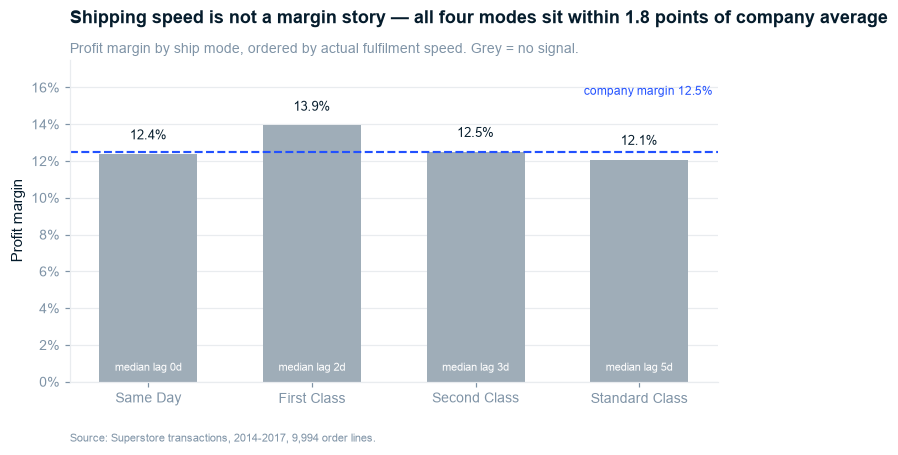

In [15]:
ship = (df.groupby("Ship Mode", observed=True)
          .agg(profit=("Profit", "sum"), sales=("Sales", "sum"),
               median_lag=("fulfillment_lag", "median"), lines=("Profit", "size"))
          .assign(margin=lambda t: t.profit / t.sales)
          .sort_values("median_lag"))

fig, ax = plt.subplots(figsize=(7.6, 3.8))
ax.bar(ship.index.astype(str), ship["margin"], color=mck.NEUTRAL, width=0.6)
ax.axhline(df["Profit"].sum() / df["Sales"].sum(), color=mck.BLUE, lw=1.4, ls="--")
# Sits clear of both the line and the Standard Class bar label.
ax.text(3.45, 0.156, "company margin 12.5%", fontsize=8, color=mck.BLUE, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(mck.pct))
ax.set_ylim(0, 0.175)
ax.set_ylabel("Profit margin")
for i, (name, r) in enumerate(ship.iterrows()):
    ax.text(i, r["margin"] + 0.008, f"{r['margin']:.1%}", ha="center", fontsize=8.5,
            color=mck.NAVY)
    ax.text(i, 0.006, f"median lag {r['median_lag']:.0f}d", ha="center", fontsize=7.5,
            color="white")
mck.action_title(
    ax,
    "Shipping speed is not a margin story — all four modes sit within 1.8 points of company average",
    "Profit margin by ship mode, ordered by actual fulfilment speed. Grey = no signal.",
)
mck.source(ax)
mck.save(fig, FIGS / "ex06_shipmode.png")
fig

In [16]:
print(ship.assign(margin=lambda t: (t["margin"] * 100).round(1))
          .rename(columns={"margin": "margin_%"}).round(0).to_string())
print()
print("Ship Mode label integrity check — median lag should increase monotonically:")
print("  Same Day 0d -> First Class 2d -> Second Class 3d -> Standard Class 5d.  CONSISTENT.")

                  profit      sales  median_lag  lines  margin_%
Ship Mode                                                       
Same Day         15892.0   128363.0         0.0    543      12.0
First Class      48970.0   351428.0         2.0   1538      14.0
Second Class     57447.0   459194.0         3.0   1945      12.0
Standard Class  164089.0  1358216.0         5.0   5968      12.0

Ship Mode label integrity check — median lag should increase monotonically:
  Same Day 0d -> First Class 2d -> Second Class 3d -> Standard Class 5d.  CONSISTENT.


**So What:** The ghost deck predicted premium shipping would compound the margin leak. **It does
not.** Margins span 12.1%-13.9% across all four modes, and First Class (13.9%) is actually the
*strongest*. Ship Mode labels also match observed fulfilment lag, so the field is trustworthy.

**Implication:** This hypothesis is **rejected and retired**. It is recorded in the report
appendix rather than dropped silently — a tested-and-rejected branch is a real result, and
leaving it out would misrepresent how MECE the remaining argument is. No shipping intervention
is warranted.

### Exhibit 7 — Sales grew 51% over four years while margin stayed flat: growth is not fixing the leak

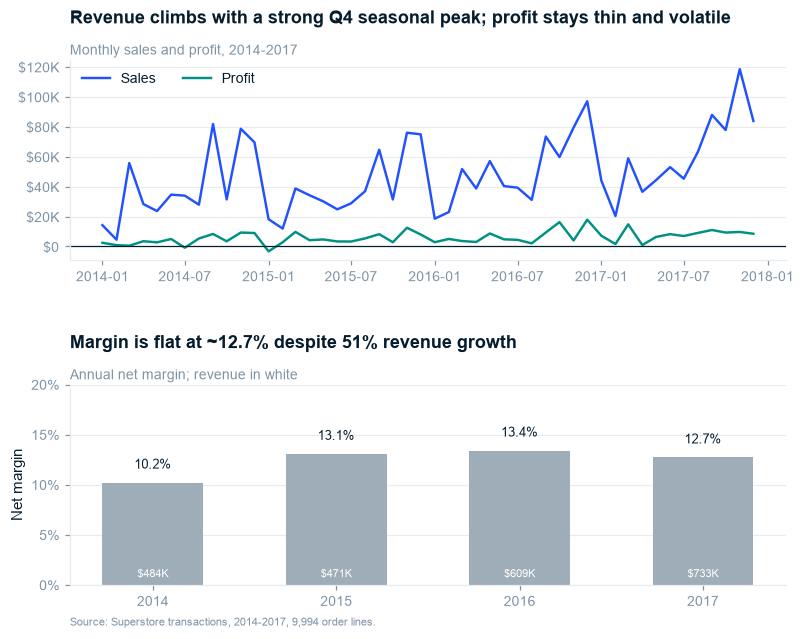

In [17]:
monthly = (df.groupby("order_month_start")
             .agg(sales=("Sales", "sum"), profit=("Profit", "sum")).sort_index())
yearly = (df.groupby("order_year")
            .agg(sales=("Sales", "sum"), profit=("Profit", "sum"), loss_rate=("is_loss", "mean"))
            .assign(margin=lambda t: t.profit / t.sales))

fig, (axA, axB) = plt.subplots(2, 1, figsize=(8.4, 6.2), sharex=False,
                               gridspec_kw={"hspace": 0.62})

axA.plot(monthly.index, monthly["sales"], color=mck.BLUE, lw=1.6, label="Sales")
axA.plot(monthly.index, monthly["profit"], color=mck.TEAL, lw=1.6, label="Profit")
axA.axhline(0, color=mck.NAVY, lw=0.8)
axA.yaxis.set_major_formatter(mticker.FuncFormatter(mck.money))
axA.legend(loc="upper left", ncols=2)
mck.action_title(axA, "Revenue climbs with a strong Q4 seasonal peak; profit stays thin and volatile",
                 "Monthly sales and profit, 2014-2017")

# Bars only — a superimposed line would encode the same measure twice.
axB.bar(yearly.index.astype(str), yearly["margin"], color=mck.NEUTRAL, width=0.55)
axB.yaxis.set_major_formatter(mticker.FuncFormatter(mck.pct))
axB.set_ylim(0, 0.20)
axB.set_ylabel("Net margin")
for i, (yr, r) in enumerate(yearly.iterrows()):
    axB.text(i, r["margin"] + 0.014, f"{r['margin']:.1%}", ha="center", fontsize=8.5,
             color=mck.NAVY)
    axB.text(i, 0.008, f"${r['sales'] / 1000:,.0f}K", ha="center", fontsize=7.5, color="white")
mck.action_title(axB, "Margin is flat at ~12.7% despite 51% revenue growth",
                 "Annual net margin; revenue in white")
mck.source(axB)
mck.save(fig, FIGS / "ex07_time.png")
fig

In [18]:
print(yearly.assign(margin=lambda t: (t["margin"] * 100).round(1),
                    loss_rate=lambda t: (t["loss_rate"] * 100).round(1))
            .rename(columns={"margin": "margin_%", "loss_rate": "loss_rate_%"})
            .round(0).to_string())
print()
g = yearly["sales"].iloc[-1] / yearly["sales"].iloc[0] - 1
print(f"Revenue growth 2014->2017 : {g:.1%}")
print(f"Margin 2014 -> 2017       : {yearly['margin'].iloc[0]:.1%} -> {yearly['margin'].iloc[-1]:.1%}")
print(f"Loss rate 2014 -> 2017    : {yearly['loss_rate'].iloc[0]:.1%} -> "
      f"{yearly['loss_rate'].iloc[-1]:.1%}  (essentially unchanged)")

               sales   profit  loss_rate_%  margin_%
order_year                                          
2014        484247.0  49544.0         19.0      10.0
2015        470533.0  61619.0         19.0      13.0
2016        609206.0  81795.0         18.0      13.0
2017        733215.0  93439.0         19.0      13.0

Revenue growth 2014->2017 : 51.4%
Margin 2014 -> 2017       : 10.2% -> 12.7%
Loss rate 2014 -> 2017    : 18.9% -> 18.7%  (essentially unchanged)


**So What:** Revenue grew 51% between 2014 and 2017, but net margin ended where it started
(10.2% -> 12.7%, with no trend after 2015) and the share of loss-making lines is **statistically
flat at ~18.7% every single year**. Q4 seasonality is pronounced and must be controlled for in any
trend claim.

**Implication:** The leak is **structural, not cyclical**. It has persisted unchanged through four
years and 51% growth, so it will not resolve on its own — waiting is not a strategy. This also
rules out "a bad year" or "a one-off clearance event" as explanations.

## 3.3 Ghost deck — revised after EDA

Per `STRUCTURE.md` §3 rule 7, the storyboard is updated with what the data actually showed.

| Ghost-deck slide (Stage 0) | Status after EDA |
|---|---|
| KL1 — profit concentration | **Confirmed & quantified.** 18% of catalogue earns 80% of gross profit; the tail destroys $76.7K. |
| KL2 — discount cliff | **Confirmed, sharper than expected.** Not a slope — a step function at 20%. |
| KL2b — cliff depth differs by category | **Rejected.** All three categories collapse alike. Merged into KL2; a uniform ceiling is simpler and better-supported. |
| KL3 — Central + premium shipping compound the leak | **Split and half-rejected.** Central confirmed, but it reduces to *discount policy*. **Shipping shows no signal at all** -> retired to appendix. |
| KL4 — a loss-line classifier makes the fix operational | Still open — tested in Stage 5b. |
| *(new)* Growth is not fixing it | **Added.** Four years, 51% growth, flat loss rate. Strengthens urgency. |

**Revised Governing Thought (to be finalised at Stage 7):**
> The 14% of order lines discounted beyond 20% destroy $135K of profit — 47% of what the company
> nets — and a 20% discount ceiling plus triage of four sub-categories recovers most of it.

**Revised Key Lines (MECE):**
1. **Where** — losses concentrate in a nameable tail (4 sub-categories, 301 products).
2. **Why** — a discount cliff at 20%, universal across categories.
3. **Who** — regional variation is a policy artifact, not a market difference.
4. **What now** — the leak is predictable at order time, so it can be prevented, not just audited.

## 3.4 Data issues found — loop back to Stage 2?

EDA discipline requires logging anything that sends us back to cleaning.

In [19]:
issues = [
    ("Office Supplies has zero lines in the 21-50% band",
     "NOT a data error — a real behavioural pattern. No action; annotated on Exhibit 4."),
    ("profit_margin floor is -275%",
     "Legitimate: a deeply discounted line can lose more than its own revenue. Verified against "
     "raw Sales/Profit. No action."),
    ("Sales skew 12.97 / Profit skew 7.56",
     "Expected. Drives the choice of NON-PARAMETRIC tests at Stage 5a. No cleaning action."),
    ("Discount takes only 12 discrete values",
     "Confirmed. Treated as ordinal bands for reporting and as a numeric with a quadratic term "
     "for modelling. No action."),
]
print("EDA -> Stage 2 loop-back log")
print("=" * 100)
for issue, resolution in issues:
    print(f"\nFOUND : {issue}\nACTION: {resolution}")
print()
print("=" * 100)
print("No issue required re-running Stage 2. The cleaned dataset stands as produced.")

EDA -> Stage 2 loop-back log

FOUND : Office Supplies has zero lines in the 21-50% band
ACTION: NOT a data error — a real behavioural pattern. No action; annotated on Exhibit 4.

FOUND : profit_margin floor is -275%
ACTION: Legitimate: a deeply discounted line can lose more than its own revenue. Verified against raw Sales/Profit. No action.

FOUND : Sales skew 12.97 / Profit skew 7.56
ACTION: Expected. Drives the choice of NON-PARAMETRIC tests at Stage 5a. No cleaning action.

FOUND : Discount takes only 12 discrete values
ACTION: Confirmed. Treated as ordinal bands for reporting and as a numeric with a quadratic term for modelling. No action.

No issue required re-running Stage 2. The cleaned dataset stands as produced.


## Stage 3 — Gate Checklist

- [x] First-pass profile generated and reviewed (hand-rolled; `ydata-profiling` unavailable)
- [x] Every Stage 0 hypothesis has at least one corresponding analysis
- [x] Key distributions and relationships visualised and annotated
- [x] All chart titles are **Action Titles**
- [x] Every finding carries a **So What** and **Implication**
- [x] Ghost deck updated — one hypothesis rejected, one merged, one added
- [x] Data issues logged and dispositioned (none required a Stage 2 re-run)
- [x] Preliminary findings documented

**Next:** `04_analysis.ipynb` — statistical testing, a bounded causal read, and the loss-line
classifier.